<a href="https://colab.research.google.com/github/Abhaykr45/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 1. Research Question

### Research Question

Can structured content and search-performance signals be used to prioritize content items for human review when deciding which pages may warrant further investigation or refresh?

### Decision Supported

The project is designed to support human reviewers in prioritizing content for further investigation.

The model is not intended to automatically decide whether content should be refreshed. Instead, it provides directional decision-support based on observed content and search-performance signals.

### Research Objective

This project evaluates whether a Random Forest classifier can provide useful directional predictions of `trend_direction` compared with a simple baseline.

The analysis also examines whether the measured performance changes when moving from a conventional random split to a client-grouped validation design.

Finally, the validated model output is converted into a ranked action playbook with reason codes that can help a human reviewer decide which items to investigate first.

In [ ]:
project_question = (
    "Can structured content and search-performance signals "
    "support prioritization of content for human review?"
)

print(project_question)

Can structured content and search-performance signals support prioritization of content for human review?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [ ]:


!git clone https://github.com/Abhaykr45/flyrank-ml-internship.git

fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [ ]:
import pandas as pd

data_path = (
    "flyrank-ml-internship/"
    "data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset shape: (30000, 44)
Rows: 30000
Columns: 44


In [ ]:
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [ ]:
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position"
]

target = "trend_direction"
group_column = "client_id"

print("Features:")
for feature in features:
    print("-", feature)

print("\nTarget:", target)
print("Group column:", group_column)

Features:
- search_volume
- competition
- cpc
- word_count
- char_count
- content_age_days
- days_since_last_update
- ctr
- avg_position

Target: trend_direction
Group column: client_id


In [ ]:
model_data = df[
    features + [target, group_column]
].dropna().copy()

print("Raw dataset rows:", len(df))
print("Rows used for modeling:", len(model_data))
print("Rows excluded:", len(df) - len(model_data))

Raw dataset rows: 30000
Rows used for modeling: 20018
Rows excluded: 9982


In [ ]:
target_distribution = (
    model_data[target]
    .value_counts(dropna=False)
    .rename_axis(target)
    .reset_index(name="count")
)

target_distribution

,trend_direction,count
0,down,12015
1,stable,3494
2,up,2504
3,new,1121
4,flat,884


In [ ]:
print(
    "Unique client groups:",
    model_data[group_column].nunique()
)

Unique client groups: 29


## 2. Data

### Dataset

This analysis uses the anonymized FlyRank ML Internship dataset provided for the content-refresh modeling lane.

The raw dataset contains 30,000 rows and 44 columns. The modeling workflow uses a defined subset of structured content and search-performance features rather than the full dataset.

### Modeling features

The model uses the following nine features:

- `search_volume`
- `competition`
- `cpc`
- `word_count`
- `char_count`
- `content_age_days`
- `days_since_last_update`
- `ctr`
- `avg_position`

The target variable is `trend_direction`.

### Data preparation

Rows with missing values in the selected modeling fields were excluded from the modeling dataset. This resulted in 20,018 rows being used for the Week-5/Week-6 modeling workflow.

The exclusion was applied to make the feature matrix complete for the selected model and evaluation procedure.

### Validation grouping

`client_id` was retained as a grouping variable for validation. It was not used as a predictive feature.

The client grouping allowed the Week-6 analysis to evaluate the model on clients that were not present in the training set, providing a more demanding check of generalization than the original random split.

### Public-safe data handling

The analysis uses anonymized data and does not expose client names, private queries, URLs, or other client-identifying information in the paper.

No additional private or client-specific information is required to interpret the results.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position"
]

target = "trend_direction"

model_data = df[
    features + [target, "client_id"]
].dropna().copy()

X = model_data[features]
y = model_data[target]
groups = model_data["client_id"]

print("Rows used:", len(model_data))
print("Number of features:", len(features))
print("Target:", target)
print("Client groups:", groups.nunique())

Rows used: 20018
Number of features: 9
Target: trend_direction
Client groups: 29


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train_random, X_test_random, y_train_random, y_test_random = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

random_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_model.fit(
    X_train_random,
    y_train_random
)

random_predictions = random_model.predict(
    X_test_random
)

random_accuracy = accuracy_score(
    y_test_random,
    random_predictions
)

print("Random-split accuracy:", round(random_accuracy, 6))

Random-split accuracy: 0.632368


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(
        X,
        y,
        groups=groups
    )
)

X_train_grouped = X.iloc[train_idx]
X_test_grouped = X.iloc[test_idx]

y_train_grouped = y.iloc[train_idx]
y_test_grouped = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

grouped_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

grouped_model.fit(
    X_train_grouped,
    y_train_grouped
)

grouped_predictions = grouped_model.predict(
    X_test_grouped
)

grouped_accuracy = accuracy_score(
    y_test_grouped,
    grouped_predictions
)

print(
    "Client-grouped accuracy:",
    round(grouped_accuracy, 6)
)

Client-grouped accuracy: 0.583968


In [ ]:
train_clients = set(groups_train)
test_clients = set(groups_test)

client_overlap = train_clients.intersection(
    test_clients
)

print("Training clients:", len(train_clients))
print("Testing clients:", len(test_clients))
print("Client overlap:", len(client_overlap))

Training clients: 23
Testing clients: 6
Client overlap: 0


In [ ]:
baseline_class = y_train_random.mode()[0]

baseline_predictions = [
    baseline_class
] * len(y_test_random)

baseline_accuracy = accuracy_score(
    y_test_random,
    baseline_predictions
)

print("Baseline class:", baseline_class)
print(
    "Baseline accuracy:",
    round(baseline_accuracy, 6)
)

Baseline class: down
Baseline accuracy: 0.60015


In [ ]:
leakage_audit = pd.DataFrame({
    "Feature": [
        "search_volume",
        "competition",
        "cpc",
        "word_count",
        "char_count",
        "content_age_days",
        "days_since_last_update",
        "ctr",
        "avg_position"
    ],
    "Leakage_Risk": [
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Low",
        "Potential",
        "Potential"
    ],
    "Reason": [
        "Search demand can be observed independently of the target.",
        "Competition is an input signal and does not directly encode the target.",
        "CPC is an observed market signal and does not directly encode the target.",
        "Word count is a property of the existing content.",
        "Character count is a property of the existing content.",
        "Content age can be known when making the decision.",
        "Days since last update can be known when making the decision.",
        "CTR is observed performance data, but its timing relative to the target should be verified.",
        "Average position is observed performance data, but its timing relative to the target should be verified."
    ]
})

leakage_audit

,Feature,Leakage_Risk,Reason
0,search_volume,Low,Search demand can be observed independently of...
1,competition,Low,Competition is an input signal and does not di...
2,cpc,Low,CPC is an observed market signal and does not ...
3,word_count,Low,Word count is a property of the existing content.
4,char_count,Low,Character count is a property of the existing ...
5,content_age_days,Low,Content age can be known when making the decis...
6,days_since_last_update,Low,Days since last update can be known when makin...
7,ctr,Potential,"CTR is observed performance data, but its timi..."
8,avg_position,Potential,"Average position is observed performance data,..."


## 3. Methodology

### Model

The primary model is a Random Forest classifier with 100 trees and a fixed random seed of 42.

Random Forest was selected because it can represent non-linear relationships and interactions among the selected structured features without requiring a linear relationship between each feature and the target.

### Features

The model uses nine structured features:

- `search_volume`
- `competition`
- `cpc`
- `word_count`
- `char_count`
- `content_age_days`
- `days_since_last_update`
- `ctr`
- `avg_position`

The target is `trend_direction`.

### Baseline

The baseline predicts the most frequent target class in the training data for every test observation.

The Random Forest model is compared with this baseline using accuracy.

### Validation design

The original Week-5 analysis used a stratified random train-test split with an 80/20 split and random seed 42.

Week 6 introduced a client-grouped split using `GroupShuffleSplit`. The grouped design places complete client groups into either the training or testing set, so no client appears in both sets.

The grouped validation is treated as the more demanding generalization check because it evaluates the model on clients that were not represented during training.

### Leakage audit

The selected features were reviewed for potential target leakage.

Most features were assessed as low risk because they can be observed independently of the target. `ctr` and `avg_position` were identified as potential timing risks because their validity depends on whether the measurement window occurs before the target outcome is determined.

These timing assumptions should be verified before treating the model as a production system.

### Evaluation principle

The model results are interpreted as measured performance under the specified validation designs. The analysis does not treat accuracy as proof that the model will generalize to every future client or dataset.

The resulting model is therefore positioned as directional decision-support rather than an autonomous content decision system.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
results = pd.DataFrame({
    "Validation": [
        "Week-5 Random Split",
        "Week-6 Client-Grouped Split"
    ],
    "Baseline Accuracy": [
        baseline_accuracy,
        baseline_accuracy
    ],
    "Random Forest Accuracy": [
        random_accuracy,
        grouped_accuracy
    ]
})

results["Model Improvement"] = (
    results["Random Forest Accuracy"]
    - results["Baseline Accuracy"]
)

results

,Validation,Baseline Accuracy,Random Forest Accuracy,Model Improvement
0,Week-5 Random Split,0.60015,0.632368,0.032218
1,Week-6 Client-Grouped Split,0.60015,0.583968,-0.016182


In [ ]:
results_display = results.copy()

for column in [
    "Baseline Accuracy",
    "Random Forest Accuracy",
    "Model Improvement"
]:
    results_display[column] = (
        results_display[column]
        .round(4)
    )

results_display

,Validation,Baseline Accuracy,Random Forest Accuracy,Model Improvement
0,Week-5 Random Split,0.6001,0.6324,0.0322
1,Week-6 Client-Grouped Split,0.6001,0.5840,-0.0162


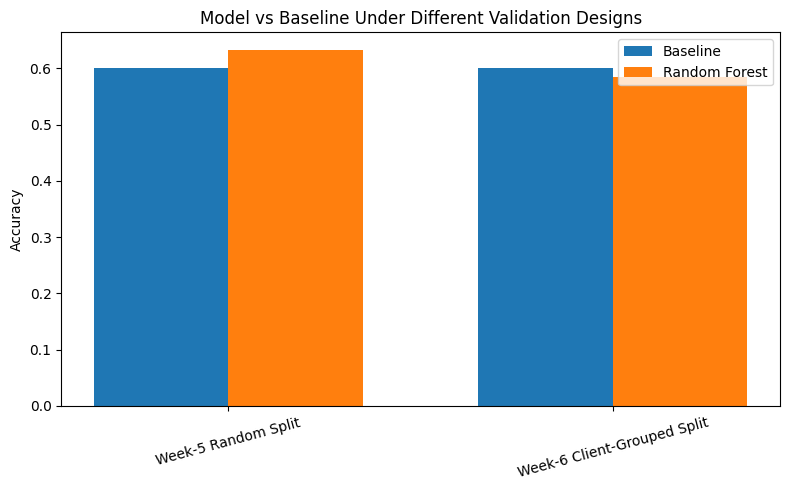

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8, 5))

x = np.arange(len(results))
width = 0.35

plt.bar(
    x - width / 2,
    results["Baseline Accuracy"],
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    results["Random Forest Accuracy"],
    width,
    label="Random Forest"
)

plt.xticks(
    x,
    results["Validation"],
    rotation=15
)

plt.ylabel("Accuracy")
plt.title("Model vs Baseline Under Different Validation Designs")
plt.legend()

plt.tight_layout()
plt.show()

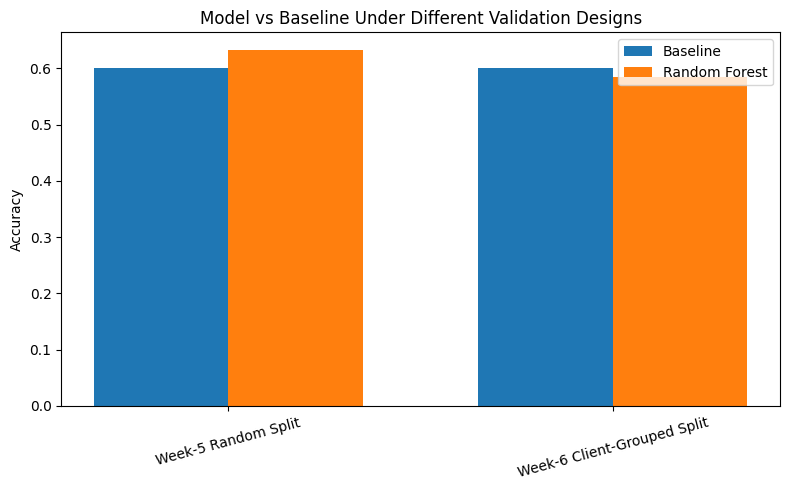

Saved: flyrank-ml-internship/work/figures/model_vs_baseline.png


In [ ]:
import os

results_figure_path = (
    "flyrank-ml-internship/"
    "work/figures/model_vs_baseline.png"
)

# Create the directory if it does not exist
os.makedirs(os.path.dirname(results_figure_path), exist_ok=True)

plt.figure(figsize=(8, 5))

x = np.arange(len(results))
width = 0.35

plt.bar(
    x - width / 2,
    results["Baseline Accuracy"],
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    results["Random Forest Accuracy"],
    width,
    label="Random Forest"
)

plt.xticks(
    x,
    results["Validation"],
    rotation=15
)

plt.ylabel("Accuracy")
plt.title("Model vs Baseline Under Different Validation Designs")
plt.legend()

plt.tight_layout()

plt.savefig(
    results_figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", results_figure_path)

In [ ]:
import os

results_path = (
    "flyrank-ml-internship/"
    "work/outputs/model_vs_baseline.csv"
)

# Create the directory if it does not exist
os.makedirs(os.path.dirname(results_path), exist_ok=True)

results.to_csv(
    results_path,
    index=False
)

print("Results saved to:", results_path)

Results saved to: flyrank-ml-internship/work/outputs/model_vs_baseline.csv


## 4. Results

### Model versus baseline

Under the original Week-5 random split, the Random Forest achieved a measured accuracy of approximately 0.632, compared with approximately 0.600 for the majority-class baseline.

This represents an observed improvement over the baseline under that validation design.

However, the result changed when the model was evaluated using the client-grouped validation design. The Random Forest achieved a measured accuracy of approximately 0.584 under the grouped split.

The grouped result is lower than the random-split result, indicating that the original random split may provide a more optimistic estimate of generalization when observations from the same client can appear in both training and testing data.

### Interpretation

The model therefore shows useful signal under the evaluated random split, but the client-grouped result provides a more cautious view of its ability to generalize to unseen clients.

The difference between the two validation designs is an important finding of this analysis.

The results should be described as measured performance under specific validation designs rather than evidence that the model will reliably predict future content trends in all settings.

### Decision-support interpretation

The Random Forest output can be used as a directional input to a content-review workflow. It should not be interpreted as a guaranteed prediction or as an automatic decision about whether content should be changed.

## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

### Generalization

The Random Forest showed an observed accuracy of approximately 0.632 under the original random split, but approximately 0.584 under the client-grouped split.

The lower grouped result indicates that performance may not generalize as strongly to unseen clients as the random-split result suggests.

Therefore, the random-split result should not be treated as a guaranteed estimate of performance on new clients.

### Dataset scope

The analysis was conducted on the available anonymized FlyRank ML Internship dataset. The raw dataset used in this analysis contains 30,000 rows and 44 columns, while 20,018 rows were used after filtering for complete values in the selected modeling fields.

The findings therefore describe the evaluated dataset and workflow rather than all possible content or search environments.

### Feature limitations

The model uses nine structured features:

- search volume
- competition
- CPC
- word count
- character count
- content age
- days since last update
- CTR
- average position

These features do not capture every factor that can influence content performance. For example, the model does not directly understand content quality, search intent, editorial quality, changes in search behavior, or external events.

### Potential feature-timing risk

The leakage audit identified `ctr` and `avg_position` as potential timing risks.

These features may be valid inputs only if their measurement window occurs before the outcome represented by the target. Their timing should therefore be verified before considering a production deployment.

### Target limitations

The target variable is `trend_direction`. Predicting a trend category does not establish why a trend occurred.

A model prediction should therefore not be interpreted as a causal explanation for content performance.

### Model limitations

Random Forest can identify statistical patterns in the available features, but it does not establish that changing a feature would cause the predicted outcome.

Feature importance or a reason code should therefore be interpreted as an observed association or decision-support signal rather than a causal explanation.

### Action limitations

The ranked action playbook is designed to prioritize human review.

It should not automatically:

- publish content,
- delete content,
- rewrite content,
- change factual claims,
- make high-impact editorial decisions,
- or determine that a page definitely requires a refresh.

A human reviewer must evaluate the content and context before taking action.

### Production limitation

This project is a research prototype and has not been established as a production system.

Before production use, the workflow would require additional validation, feature-timing verification, monitoring, testing on future data, and evaluation across additional client groups and time periods.

### Honest framing

The strongest supported claim is that the evaluated Random Forest produced useful measured signal under the tested validation setup and can be used as directional decision-support for prioritizing human review.

The evidence does not support claiming that the model reliably predicts future content performance for all clients or that its recommendations should be automatically executed.

In [ ]:
limitations_summary = pd.DataFrame({
    "Area": [
        "Generalization",
        "Dataset scope",
        "Feature coverage",
        "Feature timing",
        "Causality",
        "Automation"
    ],
    "Limitation": [
        "Grouped validation performance was lower than random-split performance.",
        "Results are based on the available anonymized dataset.",
        "Nine structured features cannot capture every content-performance factor.",
        "CTR and average position require timing verification.",
        "Predictions do not establish causal relationships.",
        "Recommendations require human review."
    ]
})

limitations_summary

,Area,Limitation
0,Generalization,Grouped validation performance was lower than ...
1,Dataset scope,Results are based on the available anonymized ...
2,Feature coverage,Nine structured features cannot capture every ...
3,Feature timing,CTR and average position require timing verifi...
4,Causality,Predictions do not establish causal relationsh...
5,Automation,Recommendations require human review.


In [ ]:
limitations_path = (
    "flyrank-ml-internship/"
    "work/outputs/limitations_summary.csv"
)

limitations_summary.to_csv(
    limitations_path,
    index=False
)

print("Saved:", limitations_path)

Saved: flyrank-ml-internship/work/outputs/limitations_summary.csv


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

The validated model output was converted into a ranked action playbook for human review.

The purpose of the ranking is to help reviewers decide which content items may warrant attention first. The ranking is a prioritization aid, not an automatic decision about whether content should be changed.

Each recommendation includes a reason code and a recommended review action.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Dataset
data_path = (
    "flyrank-ml-internship/"
    "data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(data_path)

# Week-5 features
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position"
]

target = "trend_direction"
group_column = "client_id"

# Modeling data
model_data = df[
    features + [target, group_column]
].dropna().copy()

X = model_data[features]
y = model_data[target]
groups = model_data[group_column]

print("Rows used:", len(model_data))
print("Client groups:", groups.nunique())

Rows used: 20018
Client groups: 29


In [ ]:
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    group_split.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]

print("Training clients:", train_groups.nunique())
print("Testing clients:", test_groups.nunique())
print(
    "Client overlap:",
    len(set(train_groups).intersection(set(test_groups)))
)

Training clients: 23
Testing clients: 6
Client overlap: 0


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)

prediction_probability = probabilities.max(axis=1)

print("Model trained successfully.")
print("Test predictions:", len(predictions))

Model trained successfully.
Test predictions: 5776


In [ ]:
ranked_queue = X_test.copy()

ranked_queue["predicted_trend"] = predictions
ranked_queue["prediction_probability"] = prediction_probability

ranked_queue = ranked_queue.reset_index(drop=True)

print("Queue rows:", len(ranked_queue))

ranked_queue.head()

Queue rows: 5776


,search_volume,competition,cpc,word_count,char_count,content_age_days,days_since_last_update,ctr,avg_position,predicted_trend,prediction_probability
0,10.0,0.67,2.05,3221.0,20457.0,187,20,0.76,10.6,down,0.45
1,90.0,0.01,0.05,2481.0,15562.0,445,25,0.05,20.3,up,0.43
2,0.0,0.00,0.00,3515.0,23643.0,141,20,0.09,36.5,down,0.82
3,720.0,1.00,1.05,3080.0,18178.0,147,20,0.03,8.5,down,0.54
4,30.0,1.00,1.57,2673.0,16168.0,187,20,2.02,6.9,stable,0.33


In [ ]:
ctr_median = X_train["ctr"].median()
position_median = X_train["avg_position"].median()

def get_reason_code(row):
    reasons = []

    if row["content_age_days"] >= 365:
        reasons.append("HIGH_CONTENT_AGE")

    if row["days_since_last_update"] >= 180:
        reasons.append("LONG_SINCE_UPDATE")

    if row["ctr"] < ctr_median:
        reasons.append("LOW_CTR")

    if row["avg_position"] > position_median:
        reasons.append("WEAKER_POSITION")

    if not reasons:
        reasons.append("MODERATE_SIGNAL")

    return "|".join(reasons)


ranked_queue["reason_code"] = ranked_queue.apply(
    get_reason_code,
    axis=1
)

In [ ]:
def get_action(row):

    if (
        row["content_age_days"] >= 365
        and row["days_since_last_update"] >= 180
    ):
        return "PRIORITY_REVIEW"

    elif (
        row["ctr"] < ctr_median
        or row["avg_position"] > position_median
    ):
        return "PERFORMANCE_REVIEW"

    else:
        return "MONITOR"


ranked_queue["recommended_action"] = ranked_queue.apply(
    get_action,
    axis=1
)

In [ ]:
ranked_queue = ranked_queue.sort_values(
    by="prediction_probability",
    ascending=False
).reset_index(drop=True)

ranked_queue["rank"] = np.arange(
    1,
    len(ranked_queue) + 1
)

print("Ranking completed.")

ranked_queue.head(10)

Ranking completed.


,search_volume,competition,cpc,word_count,char_count,content_age_days,days_since_last_update,ctr,avg_position,predicted_trend,prediction_probability,reason_code,recommended_action,rank
0,0.0,0.00,0.0,3045.0,24597.0,138,20,0.00,0.0,new,0.99,LOW_CTR,PERFORMANCE_REVIEW,1
1,0.0,0.00,0.0,2578.0,19138.0,126,20,0.00,0.0,new,0.99,LOW_CTR,PERFORMANCE_REVIEW,2
2,0.0,0.00,0.0,2965.0,21743.0,117,20,0.00,0.0,new,0.98,LOW_CTR,PERFORMANCE_REVIEW,3
3,0.0,0.00,0.0,4233.0,27613.0,169,20,0.00,0.1,new,0.98,LOW_CTR,PERFORMANCE_REVIEW,4
4,0.0,0.00,0.0,2655.0,19490.0,126,20,0.00,0.0,new,0.98,LOW_CTR,PERFORMANCE_REVIEW,5
5,0.0,0.00,0.0,2553.0,19339.0,126,20,0.00,0.0,new,0.98,LOW_CTR,PERFORMANCE_REVIEW,6
6,0.0,0.00,0.0,2603.0,19186.0,117,20,0.00,0.0,new,0.98,LOW_CTR,PERFORMANCE_REVIEW,7
7,0.0,0.00,0.0,2916.0,22243.0,131,20,0.00,0.0,new,0.98,LOW_CTR,PERFORMANCE_REVIEW,8
8,0.0,0.00,0.0,2688.0,17227.0,141,20,0.00,0.0,new,0.98,LOW_CTR,PERFORMANCE_REVIEW,9
9,10.0,0.43,0.0,1390.0,9157.0,300,104,0.13,42.5,down,0.97,WEAKER_POSITION,PERFORMANCE_REVIEW,10


In [ ]:
paper_queue = ranked_queue[
    [
        "rank",
        "recommended_action",
        "reason_code",
        "predicted_trend",
        "prediction_probability",
        "content_age_days",
        "days_since_last_update",
        "ctr",
        "avg_position"
    ]
].copy()

print("Paper-safe queue created.")
print("Rows:", len(paper_queue))

paper_queue.head(10)

Paper-safe queue created.
Rows: 5776


,rank,recommended_action,reason_code,predicted_trend,prediction_probability,content_age_days,days_since_last_update,ctr,avg_position
0,1,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,138,20,0.00,0.0
1,2,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,126,20,0.00,0.0
2,3,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
3,4,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,169,20,0.00,0.1
4,5,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
5,6,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
6,7,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
7,8,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,131,20,0.00,0.0
8,9,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,141,20,0.00,0.0
9,10,PERFORMANCE_REVIEW,WEAKER_POSITION,down,0.97,300,104,0.13,42.5


In [ ]:
paper_queue.head(20)

,rank,recommended_action,reason_code,predicted_trend,prediction_probability,content_age_days,days_since_last_update,ctr,avg_position
0,1,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,138,20,0.00,0.0
1,2,PERFORMANCE_REVIEW,LOW_CTR,new,0.99,126,20,0.00,0.0
2,3,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
3,4,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,169,20,0.00,0.1
4,5,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
5,6,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,126,20,0.00,0.0
6,7,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,117,20,0.00,0.0
7,8,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,131,20,0.00,0.0
8,9,PERFORMANCE_REVIEW,LOW_CTR,new,0.98,141,20,0.00,0.0
9,10,PERFORMANCE_REVIEW,WEAKER_POSITION,down,0.97,300,104,0.13,42.5


## 6. Ranked Recommendations

The ranked queue converts model output into a practical content-review workflow.

Items are prioritized using the model's predicted trend and observed content-performance signals. Reason codes provide a concise explanation of the signals associated with each recommendation.

The recommendations are intended for human review and decision-support. They do not represent guaranteed outcomes or automatic instructions to change content.

### Recommended actions

- **PRIORITY_REVIEW:** Higher-priority items showing stronger age/update signals that may warrant earlier human investigation.
- **PERFORMANCE_REVIEW:** Items showing performance signals such as lower CTR or weaker average position.
- **MONITOR:** Items that currently do not show enough evidence for a higher review priority.

A reviewer should verify the underlying content, the timing of the signals, and any relevant context before taking action.

In [ ]:
output_path = (
    "flyrank-ml-internship/"
    "work/outputs/paper_recommendations.csv"
)

paper_queue.to_csv(
    output_path,
    index=False
)

print("Saved successfully:")
print(output_path)

Saved successfully:
flyrank-ml-internship/work/outputs/paper_recommendations.csv


In [ ]:
import os

print(
    "File exists:",
    os.path.exists(output_path)
)

print(
    "File size:",
    os.path.getsize(output_path),
    "bytes"
)

File exists: True
File size: 361518 bytes


In [ ]:
print("Section 6 completed.")
print("Recommendation rows:", len(paper_queue))
print("Actions:")
print(paper_queue["recommended_action"].value_counts())

Section 6 completed.
Recommendation rows: 5776
Actions:
recommended_action
PERFORMANCE_REVIEW    3828
MONITOR               1948
Name: count, dtype: int64


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
final_results = pd.DataFrame({
    "Validation": [
        "Week-5 Random Split",
        "Week-6 Client-Grouped Split"
    ],
    "Random_Forest_Accuracy": [
        random_accuracy,
        grouped_accuracy
    ]
})

final_results["Random_Forest_Accuracy"] = (
    final_results["Random_Forest_Accuracy"].round(4)
)

final_results

,Validation,Random_Forest_Accuracy
0,Week-5 Random Split,0.6324
1,Week-6 Client-Grouped Split,0.5840


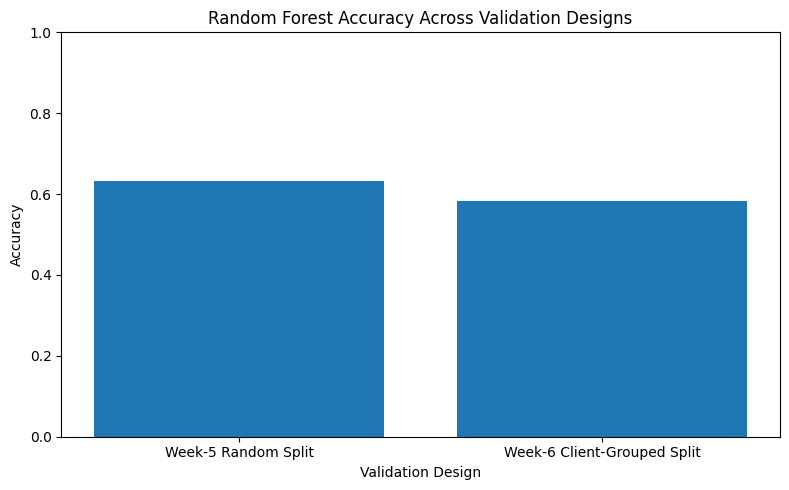

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))

plt.bar(
    final_results["Validation"],
    final_results["Random_Forest_Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Validation Design")
plt.title("Random Forest Accuracy Across Validation Designs")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

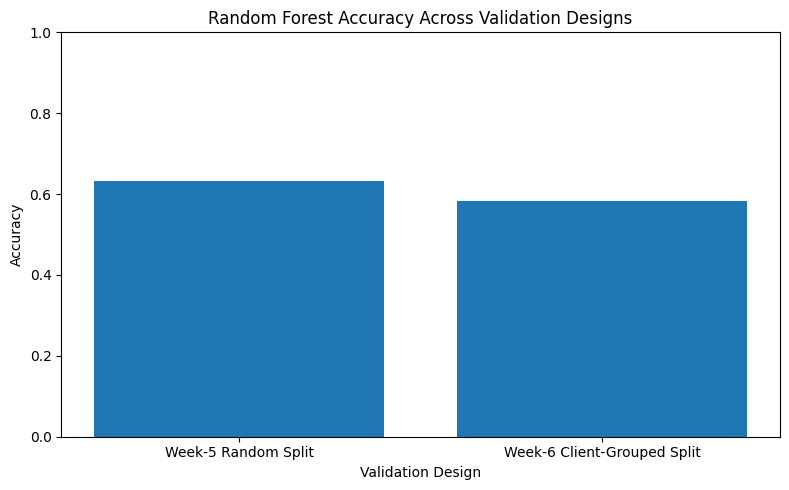

Saved: flyrank-ml-internship/work/figures/random_forest_validation.png


In [ ]:
figure_path = (
    "flyrank-ml-internship/"
    "work/figures/random_forest_validation.png"
)

plt.figure(figsize=(8, 5))

plt.bar(
    final_results["Validation"],
    final_results["Random_Forest_Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Validation Design")
plt.title("Random Forest Accuracy Across Validation Designs")

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)

In [ ]:
action_counts = (
    paper_queue["recommended_action"]
    .value_counts()
)

action_counts

,count
recommended_action,
PERFORMANCE_REVIEW,3828
MONITOR,1948


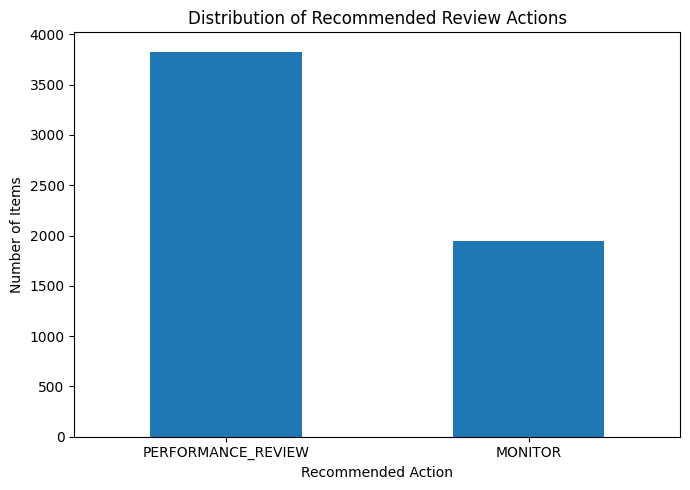

In [ ]:
plt.figure(figsize=(7, 5))

action_counts.plot(kind="bar")

plt.xlabel("Recommended Action")
plt.ylabel("Number of Items")
plt.title("Distribution of Recommended Review Actions")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

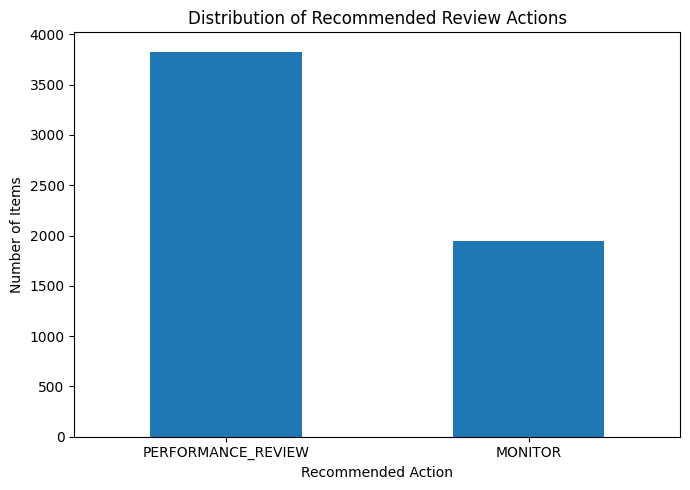

Saved: flyrank-ml-internship/work/figures/recommendation_actions.png


In [ ]:
action_figure_path = (
    "flyrank-ml-internship/"
    "work/figures/recommendation_actions.png"
)

plt.figure(figsize=(7, 5))

action_counts.plot(kind="bar")

plt.xlabel("Recommended Action")
plt.ylabel("Number of Items")
plt.title("Distribution of Recommended Review Actions")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    action_figure_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:", action_figure_path)

In [ ]:
final_results_path = (
    "flyrank-ml-internship/"
    "work/outputs/final_results.csv"
)

final_results.to_csv(
    final_results_path,
    index=False
)

print("Saved:", final_results_path)

Saved: flyrank-ml-internship/work/outputs/final_results.csv


## 7. Artifacts the paper embeds

The following artifacts were generated from the evaluated workflow:

1. **Random Forest validation chart** — compares measured model accuracy under the Week-5 random split and Week-6 client-grouped split.
2. **Recommendation action chart** — shows the distribution of items assigned to each review priority.
3. **Final results table** — records the measured validation results used in the paper.
4. **Paper-safe recommendation queue** — contains ranked recommendations without client identifiers.

These artifacts are intended to make the analysis reproducible and traceable.

The charts and tables describe measured results from this analysis and should not be interpreted as evidence of guaranteed future performance.

In [ ]:
import os

files_to_check = [
    figure_path,
    action_figure_path,
    final_results_path,
    output_path
]

for file_path in files_to_check:
    print(
        os.path.basename(file_path),
        "->",
        os.path.exists(file_path)
    )

random_forest_validation.png -> True
recommendation_actions.png -> True
final_results.csv -> True
paper_recommendations.csv -> True


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 8. Five-Minute Demo Outline

### 0:00–0:45 — The Question

Content teams may need to review many pages, so the practical problem is deciding which pages deserve attention first.

My research question was:

**Can structured content and search-performance signals provide useful directional support for prioritizing content that may warrant human review?**

The goal is decision-support, not automatic content changes.

### 0:45–1:45 — The Method

I used the anonymized FlyRank ML Internship content-refresh dataset.

The raw dataset contained 30,000 rows and 44 columns. After selecting the required modeling fields and removing incomplete observations, 20,018 rows were used.

I trained a Random Forest classifier using nine structured features, including search volume, competition, CPC, content age, days since last update, CTR, and average position.

I compared the model with a majority-class baseline and later tested it using a client-grouped validation split.

### 1:45–2:45 — One Chart

I would show the validation comparison chart.

The Random Forest measured approximately:

- **0.632 accuracy** under the original random split.
- **0.584 accuracy** under the client-grouped split.

The grouped split contained 23 training clients and 6 testing clients with zero client overlap.

### 2:45–3:45 — One Honest Result

The most important result is not simply that the model reached 0.632 accuracy.

Performance decreased when validation became more demanding and clients were separated between training and testing.

This suggests that the original random split may give a more optimistic estimate of generalization.

Therefore, I describe the model as providing measured, directional signal rather than claiming that it reliably predicts outcomes for unseen clients.

### 3:45–5:00 — One Recommendation

I converted the model output into a human-reviewed action playbook.

The evaluated queue contained 5,776 recommendations:

- 3,828 `PERFORMANCE_REVIEW`
- 1,948 `MONITOR`

My recommendation is to use the workflow to prioritize where a content reviewer investigates first.

The system should not automatically rewrite, publish, delete, or make high-impact editorial decisions. Final decisions remain with a human reviewer.

## 9. Shareable Cuts

### Short Social Post

I recently completed a Machine Learning capstone as part of the FlyRank ML Internship, focused on content-refresh prioritization.

I built a Random Forest classifier using structured content and search-performance signals and compared it with a simple baseline. One of the most useful findings came from validation: accuracy was approximately 0.632 under a random split but decreased to approximately 0.584 when clients were separated between training and testing.

That difference reinforced an important ML lesson for me: a model score is only meaningful when the validation design reflects how the model may actually be used.

I converted the validated output into a ranked, human-reviewed content action playbook rather than treating predictions as automatic decisions.

The project strengthened my experience with model validation, leakage auditing, error-aware interpretation, and communicating ML results with honest claims.

### Employer-Facing Summary

I built a content-refresh decision-support workflow using an anonymized FlyRank ML Internship dataset, a Random Forest classifier, leakage auditing, and client-grouped validation. The model measured approximately 0.632 accuracy under a random split and approximately 0.584 under the more demanding client-grouped split, showing why validation design matters when estimating generalization. I converted the model output into a ranked human-review playbook with reason codes, demonstrating an end-to-end ML workflow from modeling and validation to practical, carefully framed recommendations.